In [12]:
#Imports and directory
import os
import pickle
import random
import math
import numpy as np
import pandas as pd
import matplotlib
import torch
import torch.nn as nn
from matplotlib import pyplot as plt
os.chdir("/home/ec2-user/CS-230-Deep-Learning-Project")
#os.chdir(r"C:\VScode\Projet Stanford CS230\CS-230-Deep-Learning-Project")
#os.chdir(r"C:\Users\gotta\OneDrive\Documents\Bureau\X\4A\US\Stanford\Classes\CS 230\Project\CS-230-Deep-Learning-Project")

In [13]:
# Répertoire
data_dir = "data/Datasets_normalized"

# Charger pkl
train_df = pd.read_pickle(os.path.join(data_dir, "train_set_normalized.pkl"))
dev_df   = pd.read_pickle(os.path.join(data_dir, "dev_set_normalized.pkl"))
test_df  = pd.read_pickle(os.path.join(data_dir, "test_set_normalized.pkl"))

In [14]:
import torch
import numpy as np

# Colonnes features et target
feature_cols = ['EUR/MWh','Load_DA','Wind_DA','Solar_DA','cos_hour','sin_hour', 'cos_day','sin_day', 'cos_month', 'sin_month']
target_col = 'y'

def df_to_tensor(df, feature_cols):
    # Convert each column into a (N, 168) array, then stack along the last dimension
    arr = np.stack([np.vstack(df[col].values) for col in feature_cols], axis=2)
    return torch.tensor(arr, dtype=torch.float32)


X_train = df_to_tensor(train_df, feature_cols)
X_dev   = df_to_tensor(dev_df, feature_cols)
X_test  = df_to_tensor(test_df, feature_cols)

Y_train = torch.tensor(train_df[target_col].apply(lambda x: x[0]).values, dtype=torch.float32).unsqueeze(1)
Y_dev   = torch.tensor(dev_df[target_col].apply(lambda x: x[0]).values, dtype=torch.float32).unsqueeze(1)
Y_test  = torch.tensor(test_df[target_col].apply(lambda x: x[0]).values, dtype=torch.float32).unsqueeze(1)


# Vérification des shapes
print(X_train.shape, Y_train.shape)
print(X_dev.shape, Y_dev.shape)
print(X_test.shape, Y_test.shape)


torch.Size([63788, 168, 10]) torch.Size([63788, 1])
torch.Size([10264, 168, 10]) torch.Size([10264, 1])
torch.Size([27073, 168, 10]) torch.Size([27073, 1])


In [15]:

class ConvModel1(nn.Module):
    def __init__(self):
        super().__init__()
        
        # Convolution
        self.conv_layer1 = nn.Sequential(
            nn.Conv1d(in_channels=10, out_channels=168, kernel_size=3, padding=1),
            nn.BatchNorm1d(168),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),  # Longueur: 168 -> 84
            nn.Dropout(0.2)
        )

        self.conv_layer2 = nn.Sequential(
            nn.Conv1d(in_channels=168, out_channels=84, kernel_size=3, padding=1),
            nn.BatchNorm1d(84),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),  # Longueur: 84 -> 42
            nn.Dropout(0.2)
        )

        # Fully connected layers
        self.mlp = nn.Sequential(
            nn.Linear(84 * 42, 48),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(48, 24),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(24, 6),
            nn.ReLU(),

            nn.Linear(6, 3),
            nn.ReLU(),

            nn.Linear(3, 1)
        )

    def forward(self, x):
        # x shape: (batch, 168, 10)
        x = x.permute(0, 2, 1)  # (batch, 10, 168)
        x = self.conv_layer1(x)      # -> (batch, 168, 84)
        x = self.conv_layer2(x)      # -> (batch, 84, 42)
        x = x.flatten(1)         # (batch, 84*42)
        x = self.mlp(x)          # (batch, 1)
        return x



In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# -------------------------
# Device
# -------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# -------------------------
# Model
# -------------------------
model = ConvModel1().to(device)

# -------------------------
# He (Kaiming) initialization
# -------------------------
def init_he(m):
    if isinstance(m, nn.Conv1d) or isinstance(m, nn.Linear):
        nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
        if m.bias is not None:
            nn.init.zeros_(m.bias)

model.apply(init_he)

# -------------------------
# Training parameters
# -------------------------
epochs = 40
batch_size = 64

# -------------------------
# Loss + Optimizer
# -------------------------
criterion = nn.L1Loss()
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)

scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer, 
    T_max=epochs,  # Nombre d'itérations pour une demi-période de cosinus
    eta_min=1e-6       # Le LR minimum que vous voulez atteindre (pour ne pas tomber à 0)
)



# -------------------------
# Dataloaders
# -------------------------
train_dataset = TensorDataset(X_train, Y_train)
dev_dataset   = TensorDataset(X_dev, Y_dev)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
dev_loader   = DataLoader(dev_dataset, batch_size=batch_size, shuffle=False)

# -------------------------
# Training loop
# -------------------------
train_losses = []
dev_losses = []

for epoch in range(epochs):
    # ===== TRAIN =====
    model.train()
    running_loss = 0.0
    for X, y in train_loader:
        X, y = X.to(device), y.to(device)
        optimizer.zero_grad()
        preds = model(X)
        loss = criterion(preds, y)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * X.size(0)  # weighted by batch size

    train_loss = running_loss / len(train_dataset)
    train_losses.append(train_loss)

    # ===== VALIDATION =====
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for X, y in dev_loader:
            X, y = X.to(device), y.to(device)
            preds = model(X)
            loss = criterion(preds, y)
            val_loss += loss.item() * X.size(0)

    dev_loss = val_loss / len(dev_dataset)
    dev_losses.append(dev_loss)

    scheduler.step()
    current_lr = optimizer.param_groups[0]['lr']

    print(f"Epoch {epoch+1}/{epochs} - LR: {current_lr:.2e} - Train: {train_loss:.5f} | Dev: {dev_loss:.5f}")

print("Training Finished.")


Epoch 1/40 - LR: 9.98e-04 - Train: 0.20911 | Dev: 0.35994
Epoch 2/40 - LR: 9.94e-04 - Train: 0.13051 | Dev: 0.31232
Epoch 3/40 - LR: 9.86e-04 - Train: 0.11248 | Dev: 0.34656
Epoch 4/40 - LR: 9.76e-04 - Train: 0.09737 | Dev: 0.32558
Epoch 5/40 - LR: 9.62e-04 - Train: 0.09079 | Dev: 0.32061
Epoch 6/40 - LR: 9.46e-04 - Train: 0.08291 | Dev: 0.33415
Epoch 7/40 - LR: 9.26e-04 - Train: 0.08056 | Dev: 0.31886
Epoch 8/40 - LR: 9.05e-04 - Train: 0.07776 | Dev: 0.28292
Epoch 9/40 - LR: 8.80e-04 - Train: 0.07491 | Dev: 0.28828
Epoch 10/40 - LR: 8.54e-04 - Train: 0.07267 | Dev: 0.30596
Epoch 11/40 - LR: 8.25e-04 - Train: 0.07073 | Dev: 0.27948
Epoch 12/40 - LR: 7.94e-04 - Train: 0.06794 | Dev: 0.32845
Epoch 13/40 - LR: 7.61e-04 - Train: 0.06717 | Dev: 0.33315
Epoch 14/40 - LR: 7.27e-04 - Train: 0.06602 | Dev: 0.31694
Epoch 15/40 - LR: 6.92e-04 - Train: 0.06423 | Dev: 0.31996
Epoch 16/40 - LR: 6.55e-04 - Train: 0.06338 | Dev: 0.29879
Epoch 17/40 - LR: 6.17e-04 - Train: 0.06310 | Dev: 0.31284
Epoch 

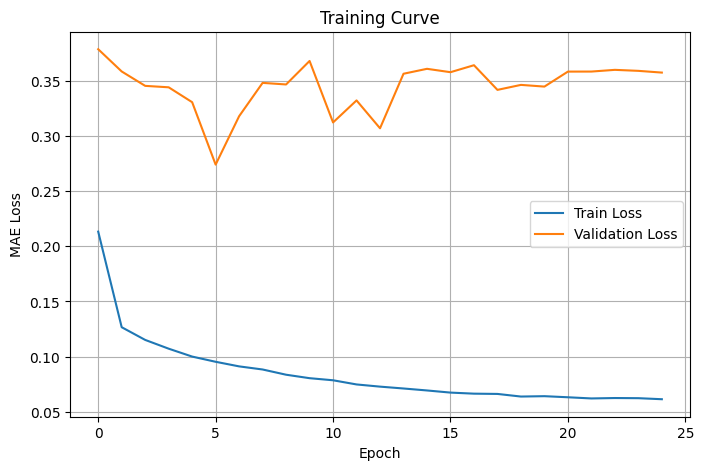

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(train_losses, label="Train Loss")
plt.plot(dev_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("MAE Loss")
plt.title("Training Curve")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:

#torch.save(model.state_dict(), "convmodel1_weights3.pth")
#print("Model weights saved to convmodel1_weights3.pth")


In [ ]:
# # Passer le modèle en mode évaluation
# model.eval()

# # Fonction pratique pour faire des prédictions
# def predict(model, X, device):
#     model.to(device)
#     X = X.to(device)
#     with torch.no_grad():
#         preds = model(X)
#     return preds.cpu().numpy()  # renvoie numpy pour analyse ou sauvegarde

# # Prédictions
# train_preds = predict(model, X_train, device)
# dev_preds   = predict(model, X_dev, device)
# test_preds  = predict(model, X_test, device)

# # Vérification
# print("Train predictions shape:", train_preds.shape)
# print("Dev predictions shape:  ", dev_preds.shape)
# print("Test predictions shape: ", test_preds.shape)


In [ ]:
from torch.utils.data import DataLoader, TensorDataset

def predict_in_batches(model, X, device, batch_size=32):
    model.eval()
    dataset = TensorDataset(X)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)
    preds = []

    with torch.no_grad():
        for (x_batch,) in loader:
            x_batch = x_batch.to(device)
            pred = model(x_batch)
            preds.append(pred.cpu())
    preds = torch.cat(preds, dim=0)
    return preds.numpy().flatten()

# -------------------------
# Prédictions batchées
# -------------------------
train_preds = predict_in_batches(model, X_train, device, batch_size=32)
dev_preds   = predict_in_batches(model, X_dev, device, batch_size=32)
test_preds  = predict_in_batches(model, X_test, device, batch_size=32)

print("Train predictions shape:", train_preds.shape)
print("Dev predictions shape:  ", dev_preds.shape)
print("Test predictions shape: ", test_preds.shape)


Train predictions shape: (63788,)
Dev predictions shape:   (10264,)
Test predictions shape:  (27073,)


In [ ]:
import numpy as np
from sklearn.metrics import mean_absolute_error

save_path = os.path.join("data/Datasets_normalized", "normalization_stats.pkl")
with open(save_path, "rb") as f:
    norm_stats = pickle.load(f)

means = norm_stats['means']      # pandas Series ou np.array
stds  = norm_stats['stds']
medians_train = norm_stats['medians_train']       # pandas Series ou np.array
medians_dev = norm_stats['medians_dev'] 
medians_test = norm_stats['medians_test'] 
norm_cols = norm_stats['norm_cols']
print(norm_cols)
print(means)
# Pour Y, supposons que c'est une seule colonne normalisée
mean_y = means['EUR/MWh']     # si norm_cols contient le nom de Y
std_y  = stds[norm_cols[0]]
median_y = medians_train[norm_cols[0]]

def evaluate_predictions_from_std(y_true, y_pred, week_lag=168):
    """Renormalise y_true et y_pred puis calcule MAE et rMAE"""
    if isinstance(y_true, torch.Tensor):
        y_true = y_true.cpu().numpy()
    y_pred = y_pred.flatten()  # s'assurer que c'est 1D
    y_true = y_true.flatten()

    # Renormalisation
    y_true = y_true * std_y + mean_y
    y_pred = y_pred * std_y + mean_y

    metrics = {}

    metrics['MAE'] = mean_absolute_error(y_true, y_pred)

    # rMAE vs previous day
    metrics['rMAE_prev'] = mean_absolute_error(y_true, y_pred) / mean_absolute_error(y_true[7:], y_true[:-7])

    # rMAE vs previous week
    metrics['rMAE_week'] = mean_absolute_error(y_true, y_pred) / mean_absolute_error(y_true[week_lag:], y_true[:-week_lag])

    # rMAE vs median
    metrics['rMAE_median'] = mean_absolute_error(y_true, y_pred) / mean_absolute_error(y_true, np.full_like(y_true, median_y))

    return metrics


['EUR/MWh', 'Load_DA', 'Wind_DA', 'Solar_DA']
EUR/MWh       106.581373
Load_DA     51981.092058
Wind_DA      4755.713740
Solar_DA     2319.492853
dtype: float64


In [ ]:
print(median_y)

78.9


In [ ]:
print(mean_y)

106.58137345281072


In [ ]:
# -------------------------
# Générer les prédictions et calculer métriques
# -------------------------
model.eval()


metrics_train = evaluate_predictions_from_std(Y_train, train_preds)
metrics_dev   = evaluate_predictions_from_std(Y_dev, dev_preds)
metrics_test  = evaluate_predictions_from_std(Y_test, test_preds)

print("Train metrics:", metrics_train)
print("Dev metrics:  ", metrics_dev)
print("Test metrics: ", metrics_test)

Train metrics: {'MAE': 14.162242889404297, 'rMAE_prev': 0.8523155081693263, 'rMAE_week': 0.8238386712410493, 'rMAE_median': 0.26187029807692647}
Dev metrics:   {'MAE': 35.10072326660156, 'rMAE_prev': 0.9432268590492823, 'rMAE_week': 0.6739933383284028, 'rMAE_median': 0.3900431506539234}
Test metrics:  {'MAE': 19.661771774291992, 'rMAE_prev': 1.431585854584428, 'rMAE_week': 1.369595312002703, 'rMAE_median': 0.5497493859841953}


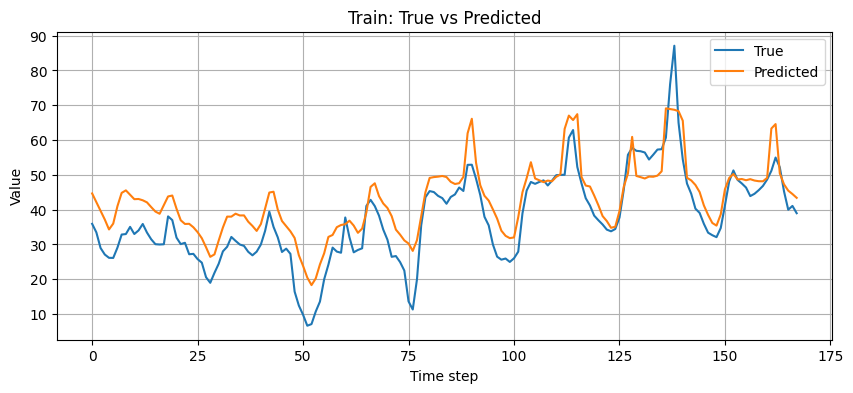

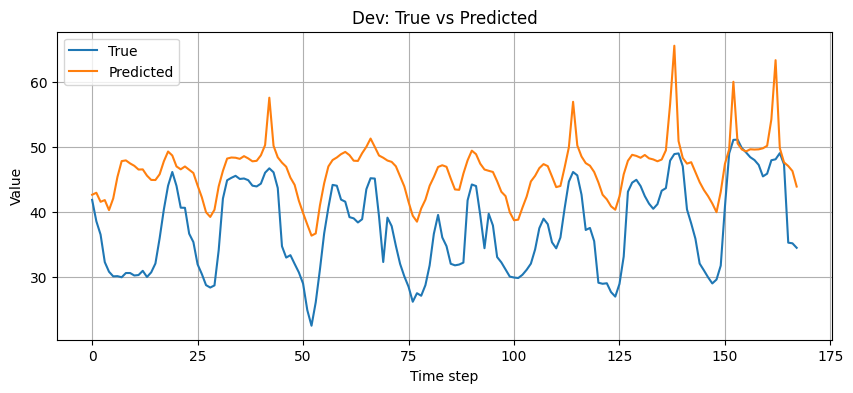

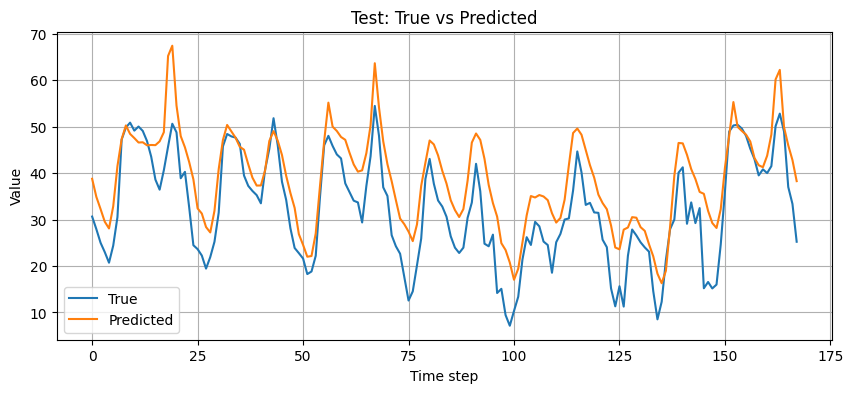

In [ ]:
def plot_first_week(y_true, y_pred, title="First Week", week_len=7*24):
    """
    Plots true vs predicted for the first week.
    y_true, y_pred: numpy arrays
    """
    y_true = np.array(y_true).flatten()
    y_pred = np.array(y_pred).flatten()

    # Renormalisation
    y_true = y_true * std_y + mean_y
    y_pred = y_pred * std_y + mean_y
    
    week_len = int(week_len)
    if len(y_true) < week_len:
        week_len = len(y_true)
    
    plt.figure(figsize=(10,4))
    plt.plot(range(week_len), y_true[:week_len], label="True")
    plt.plot(range(week_len), y_pred[:week_len], label="Predicted")
    plt.title(title)
    plt.xlabel("Time step")
    plt.ylabel("Value")
    plt.legend()
    plt.grid(True)
    plt.show()

# -------------------------
# Exemple : plot first week
# -------------------------
plot_first_week(Y_train, train_preds, title="Train: True vs Predicted")
plot_first_week(Y_dev, dev_preds, title="Dev: True vs Predicted")
plot_first_week(Y_test, test_preds, title="Test: True vs Predicted")